# 01 · Auditoría de la variable objetivo (Fase 1)

**Pregunta:** ¿la etiqueta `no_asiste` mide de verdad la inasistencia, o también mide fallas de registro?

Esto es lo primero que se revisa, porque **un modelo solo puede ser tan bueno como su etiqueta**. Si la etiqueta tiene errores sistemáticos (días sin reporte, servicios que RIPS no registra), el modelo aprende esos errores y los confunde con comportamiento del paciente.

Revisamos:
1. El pico de inasistencia de abril: ¿Semana Santa o falla de reporte?
2. PyP–Enfermería (58 % de inasistencia): ¿se reporta con otro código?
3. Inasistencia por especialidad y mes: cambios bruscos = sospecha de registro.
4. ¿RIPS tiene rezago de reporte? (define hasta qué fecha podemos usar datos)

Las funciones están en `funciones_inasistencia.py`, así que este notebook y la herramienta diaria usan exactamente las mismas reglas.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import funciones_inasistencia as fi
import funciones_modelado as fm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
fm.estilo_graficos()

## Carga y etiqueta "cruda" (antes de las correcciones)

In [2]:
fuentes = fi.cargar_fuentes(".")
rips = fi.preparar_rips(fuentes["rips"])
agenda = fi.limpiar_agendamiento(fuentes["agendamiento"])

# 'todas' = citas en la ventana con su etiqueta de asistencia, SIN aplicar las reglas de la auditoría
etiquetadas, todas, mapa_servicio, excluidas = fi.construir_citas_etiquetadas(agenda, rips)
todas["no_asiste"] = 1 - todas["asiste"]

# Versión del dataset anterior (solo las exclusiones que ya existían: lead time >= 0, terapias, reprogramadas)
antes = todas[(todas["tipo_agenda"].isin(["Consulta", "Procedimiento"]))
              & (~todas["especialidad"].isin(excluidas))
              & ~((todas["asiste"] == 0) & (todas["posible_reprogramacion"] == 1))].copy()
print(f"Citas 'antes' de la auditoría: {len(antes):,} | inasistencia {antes['no_asiste'].mean():.1%}")

Citas 'antes' de la auditoría: 407,857 | inasistencia 34.5%


## 1.1 El pico de abril: ¿Semana Santa o falla de reporte?

**Cómo distinguirlo:** si fuera Semana Santa (comportamiento), el aumento debería verse en **todas** las sedes. Si es una falla de reporte, aparece solo donde falló el sistema, y además el **volumen de RIPS** se desploma mientras la agenda sigue normal.

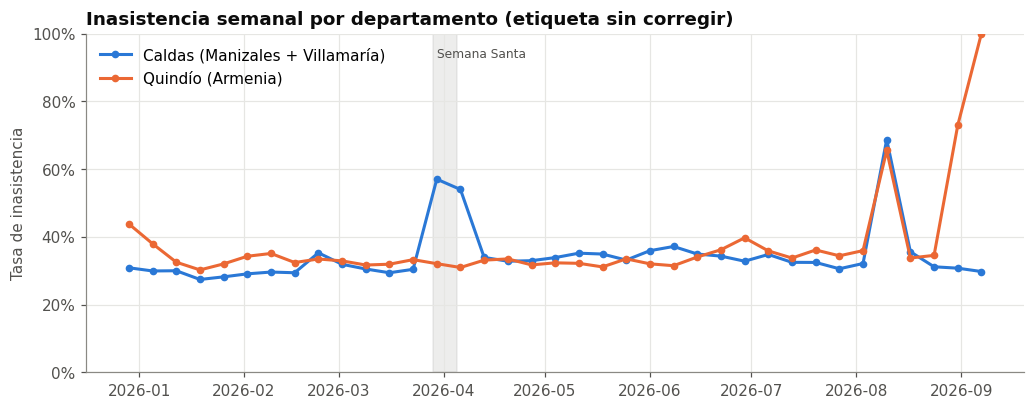

In [3]:
antes["semana"] = antes["fecha_cita"].dt.to_period("W-SUN").dt.start_time
semanal = antes.groupby(["semana", "departamento"])["no_asiste"].mean().unstack()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(semanal.index, semanal["Caldas"], color=fm.AZUL, linewidth=2, marker="o", markersize=4, label="Caldas (Manizales + Villamaría)")
ax.plot(semanal.index, semanal["Quindío"], color=fm.NARANJA, linewidth=2, marker="o", markersize=4, label="Quindío (Armenia)")
ax.axvspan(pd.Timestamp("2026-03-29"), pd.Timestamp("2026-04-05"), color=fm.GRIS, alpha=0.15)
ax.text(pd.Timestamp("2026-03-30"), 0.93, "Semana Santa", fontsize=8, color=fm.TINTA_SUAVE)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, 1)
ax.set_title("Inasistencia semanal por departamento (etiqueta sin corregir)")
ax.set_ylabel("Tasa de inasistencia")
ax.legend(loc="upper left")
plt.show()

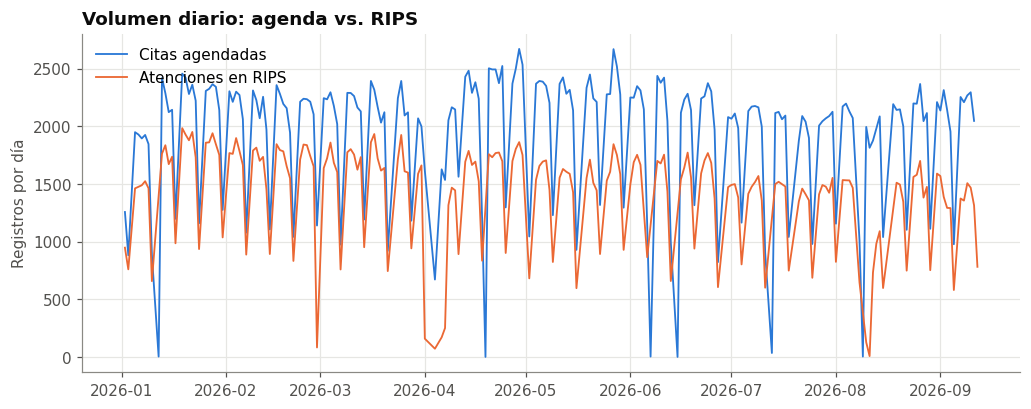

Detalle 28-mar a 10-abr (RIPS se desploma mientras la agenda sigue normal):


,citas_agendadas,atenciones_rips
2026-03-28,1182.0,942.0
2026-03-30,2069.0,1588.0
2026-03-31,1999.0,1661.0
2026-04-01,1616.0,159.0
2026-04-04,672.0,72.0
2026-04-06,1627.0,171.0
2026-04-07,1535.0,251.0
2026-04-08,2052.0,1316.0
2026-04-09,2165.0,1468.0
2026-04-10,2146.0,1445.0


In [4]:
# Volumen diario: citas agendadas (consultas) vs. atenciones registradas en RIPS
citas_dia = antes.groupby("fecha_cita").size()
rips_dia = rips.groupby("fecha_atencion").size()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(citas_dia.index, citas_dia.values, color=fm.AZUL, linewidth=1.2, label="Citas agendadas")
ax.plot(rips_dia.index, rips_dia.values, color=fm.NARANJA, linewidth=1.2, label="Atenciones en RIPS")
ax.set_title("Volumen diario: agenda vs. RIPS")
ax.set_ylabel("Registros por día")
ax.legend(loc="upper left")
plt.show()

print("Detalle 28-mar a 10-abr (RIPS se desploma mientras la agenda sigue normal):")
detalle = pd.concat([citas_dia.rename("citas_agendadas"), rips_dia.rename("atenciones_rips")], axis=1)
detalle.loc["2026-03-28":"2026-04-10"]

**Lectura:**
- **Quindío (Armenia) no se mueve en Semana Santa.** Si fuera comportamiento de los pacientes, también subiría.
- El salto se concentra en Caldas y coincide con un **desplome del volumen de RIPS** (de ~1.600 atenciones diarias a menos de 250), mientras la agenda sigue con más de 1.500 citas por día.
- Conclusión: es una **falla de reporte**, no inasistencia. El gráfico muestra otras más: 28-feb, 13-jul, la semana del 10-ago y Armenia en septiembre.

### Detección automática de días sin reporte
En vez de escribir las fechas a mano (lo que no sirve para la herramienta diaria), usamos una regla estadística: un día-departamento es anómalo si su asistencia está **muy por debajo** de lo normal.

- Usamos un **puntaje z robusto**, con **mediana** y **MAD** (mediana de desviaciones absolutas) en vez de promedio y desviación estándar. Así los propios días malos no "arrastran" el promedio.
- Regla: $z = \dfrac{\text{tasa del día} - \text{mediana}}{1.4826 \times \text{MAD}} < -4$

In [5]:
base_regla = todas[(todas["lead_time"] >= 1) & (todas["tipo_agenda"] == "Consulta") & (~todas["especialidad"].isin(excluidas))]
dias_sin_reporte = fi.detectar_dias_sin_reporte(base_regla)
print(f"Días-departamento detectados: {len(dias_sin_reporte)}")
dias_sin_reporte.assign(tasa_asistencia=lambda t: t["tasa_asistencia"].round(2), z_robusto=lambda t: t["z_robusto"].round(1))

Días-departamento detectados: 24


,departamento,fecha_cita,n_citas,tasa_asistencia,z_robusto
0,Caldas,2026-02-28,1058,0.00,-18.5
1,Caldas,2026-04-01,1550,0.00,-18.5
2,Caldas,2026-04-04,579,0.00,-18.5
3,Caldas,2026-04-06,1420,0.00,-18.5
4,Caldas,2026-04-07,1189,0.01,-18.4
5,Caldas,2026-07-13,505,0.00,-18.5
6,Caldas,2026-08-10,1802,0.06,-16.9
7,Caldas,2026-08-11,1662,0.00,-18.5
8,Caldas,2026-08-12,1614,0.30,-9.7
9,Caldas,2026-08-13,1567,0.42,-6.3


La regla detecta los vacíos completos (asistencia 0 %) y también los **parciales** (12 al 15 de agosto, cuando RIPS se fue recuperando). No marca días normales con asistencia algo baja (por ejemplo, un z de −3), porque el umbral de −4 es exigente.

> Queda un residuo menor: Armenia del 13 al 15 de agosto (z ≈ −2,5, unas 600 citas en el periodo de producción simulada). Se documenta como limitación.

## 1.2 PyP–Enfermería: ¿por qué 58 % de inasistencia?

Hipótesis: agendamiento tiene la columna `procedimiento_especifico`. Algunas citas son **procedimientos** (citología, electrocardiograma, curaciones…), que se reportan en el RIPS de **procedimientos**, no en el de **consultas** que tenemos (códigos 890xxx). Si es así, esas citas siempre "parecen" inasistencias.

In [6]:
pyp = antes[antes["especialidad"] == "PROMOCION Y PREVENCION - ENFERMERIA"]
resumen_pyp = (pyp.groupby(pyp["procedimiento_especifico"].fillna("(sin procedimiento)"))
               .agg(citas=("asiste", "size"), tasa_asistencia=("asiste", "mean"), tipo=("tipo_agenda", "first"))
               .sort_values("citas", ascending=False).head(12))
resumen_pyp.round(2)

,citas,tasa_asistencia,tipo
procedimiento_especifico,,,
ELECTROCARDIOGRAMA DE RITMO O DE SUPERFICIE SOD,5687,0.22,Procedimiento
(sin procedimiento),4595,0.60,Consulta
PLANIFICACION FAMILIAR - ENFERMERIA,4497,0.62,Consulta
CITOLOGIA,3035,0.34,Procedimiento
CONSULTA DE CONTROL EN ATENCIÓN INTEGRAL POR ENFERMERIA EN PRIMERA INFANCIA E INFANCIA,2208,0.58,Consulta
SALUD PUBLICA - ENFERMERIA,2137,0.96,Consulta
ATENCIÓN INTEGRAL EN ADOLESCENCIA POR ENFERMERA,1547,0.58,Consulta
HTA - ENFERMERIA,604,0.82,Consulta
LAVADO E IRRIGACIÓN DE OÍDOS,596,0.19,Procedimiento


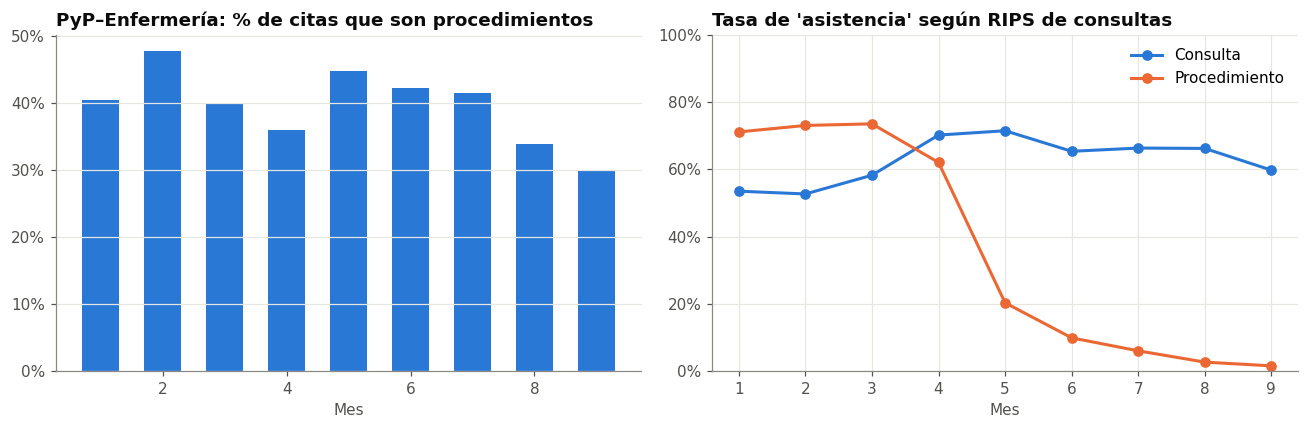

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mensual = pyp.groupby(pyp["fecha_cita"].dt.month)["tipo_agenda"].apply(lambda s: (s == "Procedimiento").mean())
axes[0].bar(mensual.index, mensual.values, color=fm.AZUL, width=0.6)
axes[0].set_title("PyP–Enfermería: % de citas que son procedimientos")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].set_xlabel("Mes")
axes[0].grid(axis="x", visible=False)

por_tipo = pyp.groupby([pyp["fecha_cita"].dt.month, "tipo_agenda"])["asiste"].mean().unstack()
axes[1].plot(por_tipo.index, por_tipo["Consulta"], color=fm.AZUL, marker="o", linewidth=2, label="Consulta")
axes[1].plot(por_tipo.index, por_tipo["Procedimiento"], color=fm.NARANJA, marker="o", linewidth=2, label="Procedimiento")
axes[1].set_title("Tasa de 'asistencia' según RIPS de consultas")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Mes")
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
# ¿Pasa lo mismo en todas las especialidades? Asistencia por tipo de agenda
comparacion = antes.groupby("tipo_agenda")["asiste"].agg(citas="size", tasa_asistencia="mean")
display(comparacion.round(3))

procedimientos = (antes[antes["tipo_agenda"] == "Procedimiento"]
                  .groupby("procedimiento_especifico")["asiste"].agg(citas="size", tasa_asistencia="mean")
                  .sort_values("citas", ascending=False).head(15))
procedimientos.round(2)

,citas,tasa_asistencia
tipo_agenda,,
Consulta,394377,0.669
Procedimiento,13480,0.231


,citas,tasa_asistencia
procedimiento_especifico,,
ELECTROCARDIOGRAMA DE RITMO O DE SUPERFICIE SOD,5687,0.22
CITOLOGIA,3035,0.34
PROCEDIMIENTOS,1514,0.17
LAVADO E IRRIGACIÓN DE OÍDOS,596,0.19
INYECCION O INFILTRACION DE ESTEROIDE,458,0.01
CURACION DE LESION EN PIEL O TEJIDO CELU,419,0.09
REEMPLAZO DE DISPOSITIVO URINARIO,386,0.18
COLPOSCOPIA,298,0.57
INSERCION DE ANTICONCEPTIVOS SUBDERMICOS,156,0.33


**Lectura:** desde abril, PyP–Enfermería pasa a agendar sobre todo procedimientos (electrocardiogramas, citologías, lavados de oído…), y estos casi nunca aparecen en el RIPS de consultas. La "inasistencia" de PyP no es comportamiento del paciente: es **qué tipo de servicio se agendó**.

**Decisión:** clasificamos cada cita como *Consulta* o *Procedimiento* con palabras clave del procedimiento agendado (función `clasificar_tipo_agenda`) y **excluimos los procedimientos**. No hay forma de verificar su asistencia con el RIPS disponible.

> `procedimiento_especifico` se conoce al agendar, así que usarlo para filtrar **no es leakage**.

## 1.3 Inasistencia por especialidad y mes: antes vs. después de las correcciones
Una especialidad cuya tasa cambia bruscamente de un mes a otro es sospechosa de un problema de registro.

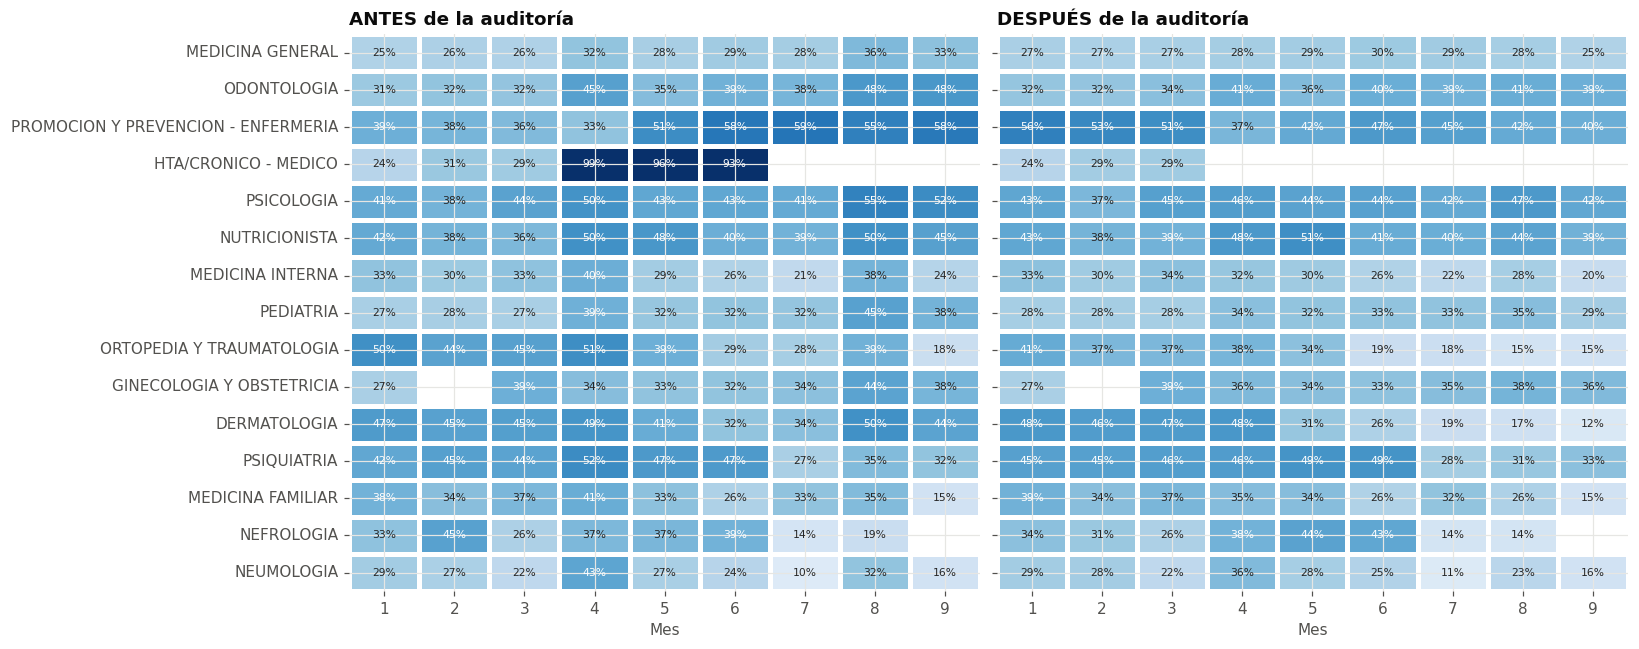

In [9]:
top = antes["especialidad"].value_counts().head(15).index

def mapa_calor(df, ax, titulo):
    datos = df[df["especialidad"].isin(top)].assign(mes=lambda t: t["fecha_cita"].dt.month)
    tabla = datos.pivot_table(index="especialidad", columns="mes", values="no_asiste", aggfunc="mean").reindex(top)
    conteo = datos.pivot_table(index="especialidad", columns="mes", values="no_asiste", aggfunc="size").reindex(top)
    tabla = tabla.where(conteo >= 100)   # celdas con menos de 100 citas no son confiables (se dejan en blanco)
    sns.heatmap(tabla, ax=ax, cmap="Blues", vmin=0, vmax=0.8, annot=True, fmt=".0%", cbar=False,
                linewidths=2, linecolor="white", annot_kws={"fontsize": 7})
    ax.set_title(titulo)
    ax.set_xlabel("Mes")
    ax.set_ylabel("")
    return tabla

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
tabla_antes = mapa_calor(antes, axes[0], "ANTES de la auditoría")
tabla_despues = mapa_calor(etiquetadas, axes[1], "DESPUÉS de la auditoría")
plt.tight_layout()
plt.show()

In [10]:
rango = pd.DataFrame({
    "rango_antes (máx - mín mensual)": (tabla_antes.max(axis=1) - tabla_antes.min(axis=1)),
    "rango_despues": (tabla_despues.max(axis=1) - tabla_despues.min(axis=1)),
}).round(2).sort_values("rango_antes (máx - mín mensual)", ascending=False)
rango

,rango_antes (máx - mín mensual),rango_despues
especialidad,,
HTA/CRONICO - MEDICO,0.75,0.06
ORTOPEDIA Y TRAUMATOLOGIA,0.33,0.26
NEUMOLOGIA,0.33,0.25
NEFROLOGIA,0.30,0.30
PROMOCION Y PREVENCION - ENFERMERIA,0.26,0.19
PSIQUIATRIA,0.25,0.21
MEDICINA FAMILIAR,0.25,0.23
ODONTOLOGIA,0.18,0.09
MEDICINA INTERNA,0.18,0.14


*(Las celdas en blanco tienen menos de 100 citas. `HTA/CRONICO - MEDICO` casi desaparece desde julio por el cambio de codificación de la agenda, ver sección 1.6.)*

**Lectura:** las correcciones estabilizan la mayoría de las especialidades (medicina general, odontología, pediatría, psicología, medicina interna). Quedan tres casos que requieren una decisión:

| Especialidad | Patrón | Interpretación | Decisión |
|---|---|---|---|
| Auxiliar en salud oral | En abril el volumen se triplica y la "inasistencia" salta de ~40 % a ~70 % | Mismo caso que higiene oral: actividades de PyP oral que se reportan como **procedimiento** | **Excluir** (parámetro `SERVICIOS_REGISTRO_INESTABLE`) |
| Dermatología | Baja gradual y constante (48 % → 12 %) | Tendencia, no salto: posible cambio real en el servicio (*drift*) | Mantener y **monitorear** |
| Nefrología | Baja en julio–septiembre | Pocas citas por mes (~300): alta variabilidad | Mantener |

In [11]:
# Verificación: auxiliar en salud oral vs. dermatología, mes a mes (etiqueta antes de excluirla)
for especialidad in ["AUXILIAR EN SALUD ORAL", "DERMATOLOGIA"]:
    datos = antes[antes["especialidad"] == especialidad]
    tabla = datos.groupby(datos["fecha_cita"].dt.month)["no_asiste"].agg(citas="size", tasa_inasistencia="mean").round(2)
    print(especialidad)
    display(tabla.T)

AUXILIAR EN SALUD ORAL


fecha_cita
citas
tasa_inasistencia


DERMATOLOGIA


fecha_cita,1,2,3,4,5,6,7,8,9
citas,407.00,570.00,613.00,707.00,615.00,545.00,460.00,538.0,242.00
tasa_inasistencia,0.47,0.45,0.45,0.49,0.41,0.32,0.34,0.5,0.44


## 1.4 ¿RIPS tiene rezago de reporte?
Antes asumimos que agosto y septiembre estaban incompletos por rezago, y por eso cortamos al 31 de julio. Lo verificamos: si hubiera rezago, la relación *atenciones RIPS / citas agendadas* caería en las últimas semanas.

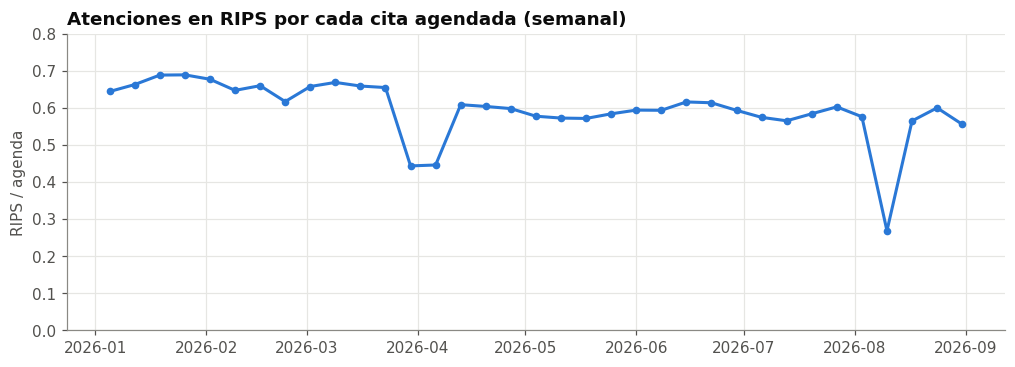

In [12]:
agenda_semana = agenda[(agenda["fecha_cita"] >= "2026-01-05") & (agenda["fecha_cita"] <= "2026-09-06")]
agenda_semana = agenda_semana.groupby(agenda_semana["fecha_cita"].dt.to_period("W-SUN").dt.start_time).size()
rips_semana = rips[(rips["fecha_atencion"] >= "2026-01-05") & (rips["fecha_atencion"] <= "2026-09-06")]
rips_semana = rips_semana.groupby(rips_semana["fecha_atencion"].dt.to_period("W-SUN").dt.start_time).size()
relacion = (rips_semana / agenda_semana)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(relacion.index, relacion.values, color=fm.AZUL, linewidth=2, marker="o", markersize=4)
ax.set_ylim(0, 0.8)
ax.set_title("Atenciones en RIPS por cada cita agendada (semanal)")
ax.set_ylabel("RIPS / agenda")
plt.show()

**Lectura:** la relación se mantiene estable (~0,55) hasta septiembre, salvo las semanas con fallas puntuales que ya detectamos. **No hay rezago sistemático.** Por lo tanto:
- Ampliamos la ventana hasta el **11-sep-2026** (el 12-sep, último día de RIPS, puede estar incompleto).
- Agosto y septiembre se usan como **"producción simulada"**: el modelo final (entrenado hasta julio) se prueba ahí como si estuviera en operación. Esto alimenta el plan de monitoreo (Fase 8.4).
- El **test sigue siendo julio** y se usa una sola vez.

## 1.5 Una regla más: el momento de predicción

El modelo predice **el día anterior a la cita (D-1)**. Eso tiene dos consecuencias que se aplican en todo el proyecto:
1. **Las citas asignadas para el mismo día (lead time = 0) no existen todavía en D-1**, así que no se pueden predecir. Se excluyen de la población del modelo.
2. **Lo que pasa en D-1 todavía no se sabe** (el día no ha terminado). Por eso el historial, los medicamentos y los diagnósticos usan información **hasta D-2** (parámetro `REZAGO_DIAS = 1`).

## 1.6 Cambio en la codificación de la agenda (abril)

Al revisar el volumen de citas por especialidad y mes aparece otro cambio de sistema. **Coincide con el cambio de nombre de las sedes** (a comienzos de abril):

In [13]:
consultas = agenda[(agenda["tipo_agenda"] == "Consulta") & (agenda["fecha_cita"] <= fi.PARAMETROS["FECHA_FIN_DATOS"])]
procedimiento = consultas["procedimiento_especifico"].fillna("").str.upper()
consultas = consultas.assign(
    codificacion=np.select(
        [consultas["especialidad"] == "HTA/CRONICO - MEDICO",
         (consultas["especialidad"] == "MEDICINA GENERAL") & procedimiento.str.contains("HTA - MEDICO"),
         consultas["especialidad"] == "MEDICINA GENERAL"],
        ["Especialidad 'HTA/CRONICO - MEDICO'", "Medicina general + procedimiento 'HTA - MEDICO'", "Medicina general (resto)"],
        default="otro"),
    mes=consultas["fecha_cita"].dt.month,
)
pd.crosstab(consultas.loc[consultas["codificacion"] != "otro", "codificacion"], consultas["mes"])

mes,1,2,3,4,5,6,7,8,9
codificacion,,,,,,,,,
Especialidad 'HTA/CRONICO - MEDICO',8382,8170,8789,1645,580,280,8,16,0
Medicina general (resto),15995,15431,16054,18287,19324,17409,18730,17059,8024
Medicina general + procedimiento 'HTA - MEDICO',663,556,598,7053,8208,8003,8686,7906,3491


**Lectura:** desde abril los controles de crónicos dejan de agendarse como `HTA/CRONICO - MEDICO` y pasan a `MEDICINA GENERAL` con el procedimiento `HTA - MEDICO`. Lo mismo ocurre con salud mental, salud pública, planificación familiar y ginecología. El servicio es el mismo; solo cambió **cómo se registra**.

**Problema:** un modelo entrenado con la codificación vieja vería en julio "medicina general" donde antes veía "crónicos", y el historial del paciente en ese servicio se "rompería" en abril.

**Decisión:** crear `servicio_homologado` (función `homologar_servicio`), que combina la especialidad con el procedimiento agendado. Ese dato se conoce al agendar, así que no es leakage. El modelo usa el servicio homologado y **no** la especialidad cruda.

In [14]:
tabla = pd.crosstab(consultas["servicio_homologado"], consultas["mes"])
tabla[tabla.sum(axis=1) > 3000]

mes,1,2,3,4,5,6,7,8,9
servicio_homologado,,,,,,,,,
AUXILIAR EN SALUD ORAL,338,335,378,1147,1054,881,1217,788,516
CONTROL PRENATAL - MEDICO,486,430,478,413,440,399,377,363,138
CRONICOS - MEDICO,9109,8888,9501,8934,9498,8364,8771,7923,3493
DERMATOLOGIA,476,604,642,688,525,448,376,387,158
ENDOCRINOLOGIA,313,329,405,488,371,488,279,460,152
FISIOTERAPIA,905,892,866,1055,951,775,737,654,333
GINECOLOGIA Y OBSTETRICIA,953,1011,1171,1171,1136,1293,1526,980,490
HIGIENE ORAL,879,1029,989,189,0,0,0,0,0
MEDICINA FAMILIAR,536,537,546,378,583,484,539,467,199


Con el servicio homologado, los volúmenes mensuales quedan continuos antes y después de abril.

### Citas "huérfanas" con códigos descontinuados
¿Qué pasa con las pocas citas que **siguen** con el código viejo después de abril?

In [15]:
descontinuados = fi.codigos_descontinuados(base_regla)
print("Códigos descontinuados detectados:", descontinuados)
base_regla = base_regla.assign(periodo=np.where(base_regla["fecha_cita"] >= fi.PARAMETROS["FECHA_CAMBIO_CODIFICACION"], "desde abril", "ene-mar"))
huerfanas = base_regla[base_regla["especialidad"].isin(descontinuados)]
huerfanas.groupby("periodo")["asiste"].agg(citas="size", tasa_asistencia="mean").round(3)

Códigos descontinuados detectados: ['ADOLESCENCIA - ENF', 'ADULTEZ - MD GRAL', 'CIRUGIA MAXILOFACIAL', 'CONTROL PRENATAL - MEDICO', 'GINECOLOGIA', 'HTA/CRONICO - MEDICO', 'INFANCIA - ENF', 'PLANIFICACION FAMILIAR - ENFERMERIA', 'PRIMERA INFANCIA - ENF', 'PRIMERA INFANCIA - MD GRAL', 'SALUD MENTAL - MD GRAL', 'SALUD PUBLICA - MEDICO', 'VEJEZ - MD GRAL']


,citas,tasa_asistencia
periodo,,
desde abril,3357,0.028
ene-mar,37586,0.641


**Lectura:** antes de abril esas citas tenían una asistencia normal. Las que quedaron con el código viejo después del cambio **casi nunca aparecen en RIPS**: son citas "huérfanas" del sistema anterior (probablemente migradas o anuladas sin marcarse como tales), no inasistencias reales.

**Decisión:** un código se considera **descontinuado** si su volumen diario cae más del 90 % desde el 1 de abril (función `codigos_descontinuados`). Sus citas desde esa fecha se excluyen. La herramienta diaria las marca como "verificar si la cita sigue vigente".

## Efecto de cada regla sobre el número de citas

In [16]:
bitacora = []
_ = fi.construir_citas_etiquetadas(agenda, rips, bitacora=bitacora)
tabla_bitacora = pd.DataFrame(bitacora)
tabla_bitacora["filas_eliminadas"] = -tabla_bitacora["filas"].diff().fillna(0).astype(int)
tabla_bitacora

Dentro de la ventana con RIPS: 483,541 filas


Asignadas al menos 1 día antes (lead time >= 1): 442,516 filas
Solo consultas (sin procedimientos): 399,008 filas
Sin terapias ni especialidades no reportadas: 381,955 filas
Sin citas huérfanas de códigos descontinuados: 378,598 filas


Sin días sin reporte en RIPS: 359,677 filas
Sin posibles reprogramaciones: 337,375 filas


,paso,filas,filas_eliminadas
0,Dentro de la ventana con RIPS,483541,0
1,Asignadas al menos 1 día antes (lead time >= 1),442516,41025
2,Solo consultas (sin procedimientos),399008,43508
3,Sin terapias ni especialidades no reportadas,381955,17053
4,Sin citas huérfanas de códigos descontinuados,378598,3357
5,Sin días sin reporte en RIPS,359677,18921
6,Sin posibles reprogramaciones,337375,22302


## Tabla de decisiones de la etiqueta (entregable Fase 1)

In [17]:
decisiones = pd.DataFrame([
    ["Pico de abril", "Falla de reporte en RIPS (no Semana Santa): Armenia no cambia y el volumen de RIPS se desploma",
     "Excluir días-departamento con asistencia anómala (z robusto < -4). Detecta también 28-feb, 13-jul, 10-15 ago y Armenia 2-11 sep"],
    ["PyP–Enfermería", "Desde abril agenda sobre todo procedimientos (ECG, citología…), que no están en el RIPS de consultas",
     "Clasificar cada cita en Consulta / Procedimiento y excluir los procedimientos (en todas las especialidades)"],
    ["Especialidad × mes", "Los saltos bruscos venían de procedimientos y días sin reporte",
     "Se estabilizan la mayoría. Auxiliar en salud oral se excluye (registro inestable desde abril); dermatología se monitorea (tendencia)"],
    ["Terapias y servicios no reportados", "Asistencia < 25 %: no se registran como consulta",
     "Excluir terapias (decisión del proyecto) + especialidades con asistencia < 25 %"],
    ["Rezago de RIPS", "No hay rezago sistemático: relación RIPS/agenda estable",
     "Ampliar datos al 11-sep. Ago-sep = producción simulada. Test = julio (sin cambios)"],
    ["Momento de predicción D-1", "Las citas del mismo día no existen en D-1 y lo de D-1 no se conoce",
     "Excluir lead time = 0 y usar información hasta D-2 en todas las variables"],
    ["Cambio de codificación de la agenda (abril)", "Crónicos, salud mental, salud pública, etc. pasan a codificarse como procedimiento dentro de medicina general / PyP",
     "Crear servicio_homologado (especialidad + procedimiento). El modelo usa el servicio homologado, no la especialidad cruda. Excluir citas 'huérfanas' con códigos descontinuados (~100 % sin registro en RIPS)"],
    ["Reprogramaciones", "Sin reporte de canceladas (confirmado por la IPS)",
     "Se mantiene la regla: no está en RIPS + otra cita de la misma especialidad pedida antes de la fecha"],
], columns=["Tema", "Hallazgo", "Decisión"])
decisiones.style.set_properties(**{"text-align": "left", "white-space": "normal"})

,Tema,Hallazgo,Decisión
0,Pico de abril,Falla de reporte en RIPS (no Semana Santa): Armenia no cambia y el volumen de RIPS se desploma,"Excluir días-departamento con asistencia anómala (z robusto < -4). Detecta también 28-feb, 13-jul, 10-15 ago y Armenia 2-11 sep"
1,PyP–Enfermería,"Desde abril agenda sobre todo procedimientos (ECG, citología…), que no están en el RIPS de consultas",Clasificar cada cita en Consulta / Procedimiento y excluir los procedimientos (en todas las especialidades)
2,Especialidad × mes,Los saltos bruscos venían de procedimientos y días sin reporte,Se estabilizan la mayoría. Auxiliar en salud oral se excluye (registro inestable desde abril); dermatología se monitorea (tendencia)
3,Terapias y servicios no reportados,Asistencia < 25 %: no se registran como consulta,Excluir terapias (decisión del proyecto) + especialidades con asistencia < 25 %
4,Rezago de RIPS,No hay rezago sistemático: relación RIPS/agenda estable,Ampliar datos al 11-sep. Ago-sep = producción simulada. Test = julio (sin cambios)
5,Momento de predicción D-1,Las citas del mismo día no existen en D-1 y lo de D-1 no se conoce,Excluir lead time = 0 y usar información hasta D-2 en todas las variables
6,Cambio de codificación de la agenda (abril),"Crónicos, salud mental, salud pública, etc. pasan a codificarse como procedimiento dentro de medicina general / PyP","Crear servicio_homologado (especialidad + procedimiento). El modelo usa el servicio homologado, no la especialidad cruda. Excluir citas 'huérfanas' con códigos descontinuados (~100 % sin registro en RIPS)"
7,Reprogramaciones,Sin reporte de canceladas (confirmado por la IPS),Se mantiene la regla: no está en RIPS + otra cita de la misma especialidad pedida antes de la fecha


In [18]:
print(f"Etiqueta final: {len(etiquetadas):,} citas | inasistencia {etiquetadas['no_asiste'].mean():.1%}")
print("El dataset se regenera en 02_Construccion_Dataset.ipynb con estas reglas.")

Etiqueta final: 337,375 citas | inasistencia 31.9%
El dataset se regenera en 02_Construccion_Dataset.ipynb con estas reglas.
